# Fixed points of feedback diagrams

A diagram with a feedback loop carries two semantics in optyx, both built from
the same open one-step channel from `dom @ memory` to `cod @ memory`:

* **stream semantics** — `to_stream` and `unroll` give the diagram at each
  finite time step;
* **fixed-point semantics** — `fix` approximates the state the loop settles
  into as time goes to infinity.

The notebook starts with the smallest experiment: one photon enters a beam
splitter at every step and the second output is fed back. Its stationary
distribution and tail make the fixed point concrete before the same two
estimators are scaled to an arbitrary multimode interferometer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from discopy.symmetric import Equation
from optyx import photonic
from optyx.channel import Channel, Diagram, Discard, qmode
from optyx.core import diagram
from optyx.core.backends import DiscopyBackend

## Part 1: one beam splitter, one photon per step

Now the smallest instance worth studying. A photon enters the first input at
every time step; the second output is fed back into the second input. The
`MZI` mixing phase `theta` sets how much of the fresh photon enters the loop,
with through-port probability $T=\sin^2(\pi\theta)$, and `phi` is an
external phase.

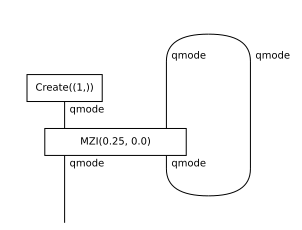

In [2]:
def learner(theta, phi=0.0):
    return (photonic.Create(1) @ qmode >> photonic.MZI(theta, phi)).feedback(
        mem=qmode, initial_state=photonic.Create(0))

learner(0.25).draw(figsize=(4, 3))

### The fixed point is a classical mixture of Fock states

Photon number is conserved by the beam splitter and the drive has a definite
number, so the memory occupation and the output occupation are perfectly
correlated; tracing out one of them destroys every coherence between different
photon numbers. The fixed point is therefore **diagonal in the Fock basis** —
a classical mixture, never a coherent state — and `phi`, being diagonal in
number, cannot affect it at all.

In [3]:
rho = learner(.06, .125).fix(method="eigen", cutoff=8).density_matrix
off_diagonal = np.abs(rho - np.diag(np.diag(rho))).max()
print(f"largest off-diagonal element: {off_diagonal:.2e}")

base = learner(.06, 0).fix(method="eigen", cutoff=8).density_matrix
for phi in (0, .125, .25, .5, .75):
    other = learner(.06, phi).fix(method="eigen", cutoff=8).density_matrix
    print(f"phi={phi:5.3f}  max difference from phi=0: "
          f"{np.abs(other - base).max():.2e}")

largest off-diagonal element: 1.44e-16


phi=0.000  max difference from phi=0: 0.00e+00


phi=0.125  max difference from phi=0: 1.12e-16


phi=0.250  max difference from phi=0: 1.39e-16


phi=0.500  max difference from phi=0: 2.22e-16


phi=0.750  max difference from phi=0: 2.04e-16


### The mean is exactly one

In the Heisenberg picture the loop mode after the beam splitter is
$b_{\mathrm{out}} = -r^* a_{\mathrm{in}} + t^* b_{\mathrm{in}}$. The Fock
input has $\langle a\rangle=0$ and a number-diagonal memory has
$\langle b\rangle=0$, so the cross terms drop and
$\bar n' = R + T\bar n$. At the fixed point $R(\bar n - 1)=0$, hence

$$\boxed{\langle n\rangle = 1}$$

for every $T<1$ — one photon enters per step, so one must leave per step. This
is exact, holds for both the loop and the output, and is the sharpest single
check on the implementation.

In [4]:
def statistics(distribution):
    n = np.arange(len(distribution))
    mean = (n * distribution).sum()
    return mean, (n * n * distribution).sum() - mean ** 2


records = []
for theta, cutoff in ((.02, 6), (.04, 7), (.06, 8), (.08, 9)):
    rho = learner(theta).fix(method="eigen", cutoff=cutoff).density_matrix
    p = np.real(np.diag(rho))
    p = p / p.sum()
    mean, variance = statistics(p)
    records.append((theta, np.sin(np.pi * theta) ** 2, mean, variance - mean, p))
    print(f"theta={theta:.2f}  T={np.sin(np.pi*theta)**2:.4f}  "
          f"mean={mean:.6f}  Q={variance-mean:+.6f}")

theta=0.02  T=0.0039  mean=1.000000  Q=-0.968707


theta=0.04  T=0.0157  mean=1.000000  Q=-0.878220


theta=0.06  T=0.0351  mean=1.000000  Q=-0.738162


theta=0.08  T=0.0618  mean=1.000000  Q=-0.562862


Every mean is `1.000000`, as the identity demands.

Note the cutoff climbing with `theta`: the closer the beam splitter gets to
50:50, the longer the tail and the larger the truncated space needed to hold
it. At exactly 50:50 `method="eigen"` refuses outright — its trace-preservation
check fails even at cutoff 22 — which is precisely the regime `method="power"`
exists for.

### The stationary distribution and its tail

`fix` returns the stationary emitted distribution plotted below. Only the
full swap gives a single Fock state. For any $T>0$ the distribution has
weight on **every** photon number; what changes with $\theta$ is how fast the
tail decays.

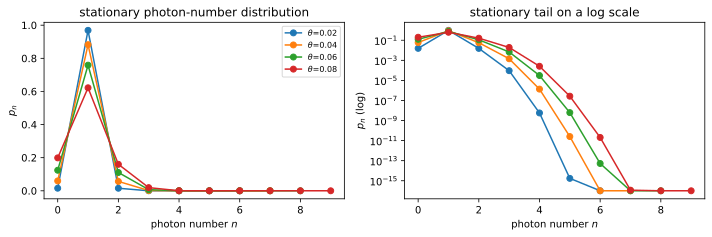

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for theta, T, mean, Q, p in records:
    occupations = np.arange(len(p))
    axes[0].plot(occupations, p, "o-", label=fr"$\theta$={theta:.2f}")
    axes[1].semilogy(occupations, np.maximum(p, 1e-16), "o-")
axes[0].set_xlabel("photon number $n$")
axes[0].set_ylabel("$p_n$")
axes[0].set_title("stationary photon-number distribution")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("photon number $n$")
axes[1].set_ylabel("$p_n$ (log)")
axes[1].set_title("stationary tail on a log scale")
figure.tight_layout()
plt.show()

## Complexity with $M$ external and $L$ feedback modes

Now generalise the experiment without introducing a separate cutoff variable.
Let $U$ be an arbitrary photon-number-preserving unitary on $M+L$ optical
modes. At every step the $M$
external inputs contain one photon each, the other $L$ inputs carry the loop
state, and $L$ outputs are fed back. Compare both estimators after $n=M$
steps.

At most $M$ new photons enter per step, so the loop contains at most $M^2$
photons. Total-photon truncation gives the loop Hilbert-space dimension

$$h(L,M)=\sum_{p=0}^{M^2}\binom{p+L-1}{L-1}
=\binom{M^2+L}{L}.$$

Write $\operatorname{cost}_{L,M}(U)$ and
$\operatorname{space}_{L,M}(U)$ for the time and workspace needed to apply
the doubled one-step channel $\rho\mapsto\operatorname{Tr}_{M}
[U(\lvert1\rangle\!\langle1\rvert^{\otimes M}\otimes\rho)U^\dagger]$.
This notation leaves $U$ arbitrary: a dense array, a permanent evaluator and
a tensor-network backend give different costs, but the fixed-point algorithms
only call the same channel.

Power applies it $M$ times:

$$T_{\mathrm{power}}(L,M,U)
=O\!\left(M\operatorname{cost}_{L,M}(U)\right),\qquad
S_{\mathrm{power}}(L,M,U)
=O\!\left(\binom{M^2+L}{L}^{2}
+\operatorname{space}_{L,M}(U)\right).$$

Eigen applies the channel to $h(L,M)^2$ operator-basis elements to form a
$h(L,M)^2\times h(L,M)^2$ transfer matrix, then diagonalises it:

$$T_{\mathrm{eigen}}(L,M,U)=O\!\left(
\binom{M^2+L}{L}^{2}\operatorname{cost}_{L,M}(U)
+\binom{M^2+L}{L}^{6}\right),$$

$$S_{\mathrm{eigen}}(L,M,U)=O\!\left(
\binom{M^2+L}{L}^{4}
+\operatorname{space}_{L,M}(U)\right).$$

In [6]:
from math import comb

print(" M   L   max photons   loop states h   density entries h^2")
for external_modes, loop_modes in ((2, 1), (2, 2), (3, 1), (3, 2), (4, 3)):
    photons = external_modes ** 2
    states = comb(photons + loop_modes, loop_modes)
    print(f" {external_modes:1d}   {loop_modes:1d}       {photons:3d}"
          f"          {states:8d}          {states ** 2:12d}")

 M   L   max photons   loop states h   density entries h^2
 2   1         4                 5                    25
 2   2         4                15                   225
 3   1         9                10                   100
 3   2         9                55                  3025
 4   3        16               969                938961


For fixed $L$, $h(L,M)\sim M^{2L}/L!$. The unitary-dependent part of power
therefore needs only $M$ channel applications, whereas constructing the eigen
problem needs approximately $M^{4L}/(L!)^2$ applications and its dense solve
costs approximately $M^{12L}/(L!)^6$. Under the stated $n=M$ assumption,
power has the better asymptotic scaling for every $L>0$. Eigen is useful only
while the loop sector is small enough that its one-time dense transfer matrix
fits in memory. This conclusion does not assume any structure in $U$ and does
not depend on whether the application of $U$ is realised by Quimb,
permanents, JAX or PyTorch.

### What `theta` does

`theta` is the only control that matters here, and it interpolates between two
degenerate extremes. Reading the one-photon transfer probability straight off
the circuit:

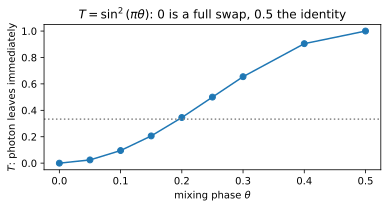

In [7]:
thetas = np.array([0, .05, .1, .15, .2, .25, .3, .4, .5])
transmission = []
for theta in thetas:
    amps = (photonic.Create(1, 0) >> photonic.MZI(theta, 0)
            ).eval(DiscopyBackend()).amplitudes()
    transmission.append(abs(amps.get((1, 0), 0)) ** 2)
transmission = np.array(transmission)

figure, axis = plt.subplots(figsize=(5.5, 3))
axis.plot(thetas, transmission, "o-")
axis.axhline(1 / 3, ls=":", color="grey")
axis.set_xlabel(r"mixing phase $\theta$")
axis.set_ylabel(r"$T$: photon leaves immediately")
axis.set_title(r"$T=\sin^2(\pi\theta)$: 0 is a full swap, 0.5 the identity")
figure.tight_layout()
plt.show()

At $\theta=0$ the beam splitter is a **full swap**: the fresh photon is
placed in the loop and the previous loop content leaves, so the loop holds
exactly one photon forever. At $\theta=0.5$ it is the **identity**: the photon
leaves immediately and the loop never fills. In between the two mix.

### Sub- or super-Poissonian, and the crossover

The Mandel parameter $Q=\mathrm{Var}(n)-\langle n\rangle$ is negative for a
number-squeezed state, zero for Poissonian statistics and positive for a
bunched one. Here it sweeps through all three: the fixed point starts at the
pure single photon ($Q=-1$), passes exactly through Poissonian statistics, and
becomes super-Poissonian as the loop decouples.

Careful though: **Poissonian statistics is not a coherent state.** The state
stays Fock-diagonal throughout, and at the crossing its distribution is not
even Poisson — only its second moment matches.

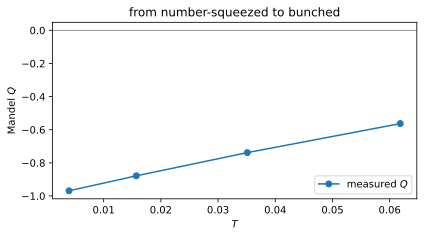

In [8]:
figure, axis = plt.subplots(figsize=(6, 3.4))
axis.plot([r[1] for r in records], [r[3] for r in records], "o-",
          label="measured $Q$")
axis.axhline(0, color="grey", lw=.8)
axis.set_xlabel("$T$")
axis.set_ylabel("Mandel $Q$")
axis.set_title("from number-squeezed to bunched")
axis.legend()
figure.tight_layout()
plt.show()

### Two different states: the loop and the emission

Worth being precise about what `fix` returns. The loop settles into a
stationary state $\rho_\star$, and what leaves through the output port is a
*different* state — the other half of the same beam splitter. Both have mean
one, by the same balance argument, but their higher moments differ, and they
coincide only at 50:50 where the two ports are symmetric. `fix` reports the
**emitted** state, because that is the diagram's codomain.

The closed form below is for the **loop**.

### The analytic anchor

Compare with **distinguishable** particles. Each loop photon independently
survives with probability $T$ and the fresh photon enters with probability
$1-T$. Write $F_r=\langle(N)_r\rangle$ for the factorial moments and
$[r]_T=1+T+\cdots+T^{r-1}$. The classical thinning chain and the bosonic
beam splitter obey

$$F_r^{\mathrm C}=\frac{r!\,T^{r(r-1)/2}}
{\prod_{j=1}^r[j]_T},\qquad
F_r^{\mathrm Q}=r!F_r^{\mathrm C}.$$

Thus $F_1=\langle N\rangle=1$ for both, while

$$F_2^{\mathrm C}=\frac{2T}{1+T},\quad
F_3^{\mathrm C}=\frac{6T^3}{(1+T)(1+T+T^2)},\quad
F_4^{\mathrm C}=\frac{24T^6}
{(1+T)(1+T+T^2)(1+T+T^2+T^3)}.$$

The quantum values multiply these by $2$, $6$ and $24$. In particular,
$\mathrm{Var}(N)=F_2$, so Hong–Ou–Mandel bunching doubles the variance and
leaves the mean alone. The third and fourth factorial moments expose an
increasing enhancement of the rare, highly occupied tail.

The cell below constructs both stationary chains independently of optyx and
checks all four moments. `skew` is the standardised third central moment and
`excess` is the excess kurtosis.

In [9]:
from math import factorial

from scipy.linalg import expm

def stationary_distribution(chain):
    values, vectors = np.linalg.eig(chain.T)
    result = np.real(vectors[:, np.argmin(np.abs(values - 1))])
    return result / result.sum()

def transfer(T, cutoff=24):
    ladder = np.diag(np.sqrt(np.arange(1, cutoff + 1)), 1)
    identity = np.eye(cutoff + 1)
    a, b = np.kron(ladder, identity), np.kron(identity, ladder)
    generator = a.conj().T @ b - a @ b.conj().T
    unitary = expm(np.arcsin(np.sqrt(1 - T)) * generator)
    to_loop = np.zeros((cutoff + 1, cutoff + 1))
    to_output = np.zeros((cutoff + 1, cutoff + 1))
    for n in range(cutoff):
        vector = np.zeros((cutoff + 1) ** 2)
        vector[cutoff + 1 + n] = 1.0
        weights = np.abs((unitary @ vector).reshape(
            cutoff + 1, cutoff + 1)) ** 2
        to_loop[n] = weights.sum(axis=0)
        to_output[n] = weights.sum(axis=1)
    chain = to_loop[:cutoff, :cutoff]
    chain = chain / chain.sum(axis=1, keepdims=True)
    loop = stationary_distribution(chain)
    emitted = loop @ to_output[:cutoff, :cutoff]
    return loop, emitted / emitted.sum()

def classical_transfer(T, cutoff=80):
    chain = np.zeros((cutoff, cutoff))
    reflection = 1 - T
    for occupation in range(cutoff):
        for survivors in range(occupation + 1):
            probability = (comb(occupation, survivors)
                           * T ** survivors
                           * reflection ** (occupation - survivors))
            chain[occupation, survivors] += T * probability
            if survivors + 1 < cutoff:
                chain[occupation, survivors + 1] += reflection * probability
    chain = chain / chain.sum(axis=1, keepdims=True)
    return stationary_distribution(chain)

def numerical_factorial_moment(distribution, order):
    occupations = np.arange(len(distribution))
    falling = np.ones(len(distribution))
    for shift in range(order):
        falling *= occupations - shift
    return distribution @ falling

def analytic_factorial_moment(T, order, quantum):
    q_factorial = np.prod([sum(T ** k for k in range(r))
                           for r in range(1, order + 1)])
    multiplicity = factorial(order) ** (2 if quantum else 1)
    return multiplicity * T ** (order * (order - 1) / 2) / q_factorial

def higher_statistics(distribution):
    moments = [numerical_factorial_moment(distribution, r)
               for r in range(1, 5)]
    mean, f2, f3, f4 = moments
    raw2 = f2 + mean
    raw3 = f3 + 3 * f2 + mean
    raw4 = f4 + 6 * f3 + 7 * f2 + mean
    variance = raw2 - mean ** 2
    central3 = raw3 - 3 * mean * raw2 + 2 * mean ** 3
    central4 = (raw4 - 4 * mean * raw3 + 6 * mean ** 2 * raw2
                - 3 * mean ** 4)
    skew = central3 / variance ** 1.5
    excess = central4 / variance ** 2 - 3
    return f2, f3, f4, skew, excess


print("   T   kind       F2        F3        F4     skew   excess")
for T in (.1, .25, 1 / 3, .5, .75):
    cases = (("classical", classical_transfer(T), False),
             ("quantum  ", transfer(T)[0], True))
    for label, distribution, quantum in cases:
        measured = higher_statistics(distribution)
        exact = [analytic_factorial_moment(T, r, quantum)
                 for r in range(2, 5)]
        assert np.allclose(measured[:3], exact, atol=1e-10)
        print(f"{T:5.3f}  {label}  {measured[0]:8.4f}  "
              f"{measured[1]:8.4f}  {measured[2]:8.4f}  "
              f"{measured[3]:7.3f}  {measured[4]:7.3f}")

   T   kind       F2        F3        F4     skew   excess


0.100  classical    0.1818    0.0049    0.0000    0.063    2.798
0.100  quantum      0.3636    0.0295    0.0004    0.134    0.199


0.250  classical    0.4000    0.0571    0.0027    0.226    0.231
0.250  quantum      0.8000    0.3429    0.0645    0.479   -0.578


0.333  classical    0.5000    0.1154    0.0115    0.326   -0.031
0.333  quantum      1.0000    0.6923    0.2769    0.692   -0.338


0.500  classical    0.6667    0.2857    0.0762    0.525   -0.043
0.500  quantum      1.3333    1.7143    1.8286    1.113    0.707


0.750  classical    0.8571    0.6255    0.3860    0.788    0.395
0.750  quantum      1.7143    3.7529    9.2643    1.672    3.290


The factorial-moment formulas agree with both stationary chains through
fourth order. Relative to distinguishable particles, bosonic interference
multiplies $F_2$, $F_3$ and $F_4$ by $2$, $6$ and $24$. The standardised
columns show that this is more than a wider Gaussian: the quantum tail also
changes its asymmetry and kurtosis.

The same construction predicts the *emitted* state, so it validates `fix`
end to end — an independent Fock-space transfer matrix against the diagrammatic
fixed point:

In [10]:
print(" theta      T      max |p_fix - p_model|")
for theta, T, mean, Q, p in records:
    emitted = transfer(T)[1]
    width = min(len(p), len(emitted))
    gap = np.abs(p[:width] - emitted[:width]).max()
    print(f" {theta:.2f}   {T:.4f}         {gap:.2e}")

 theta      T      max |p_fix - p_model|


 0.02   0.0039         1.13e-16


 0.04   0.0157         7.77e-16
 0.06   0.0351         3.33e-16


 0.08   0.0618         4.44e-16


### Answers, in short

Two consequences worth stating, since they answer the obvious questions about
this state:

* it is **not a coherent state** — it is Fock-diagonal, whereas a coherent
  state is pure with large coherences, and even where its variance is
  Poissonian its distribution is not Poisson;
* it is **not thermal** — a thermal state of mean one would have $Q=+1$, which
  the family only approaches as the loop decouples entirely.

## Part 2: boson sampling with optical feedback

Use $M$ external input/output modes and $L$ feedback modes. Biriukov and
Dyakonov inject a fixed bosonic product state $\psi$ into the external modes,
apply an arbitrary $(M+L)$-mode unitary $U$, expose the $M$ outputs and feed
the remaining $L$ outputs back as memory. The example below has $M=2$ and
$L=1$.

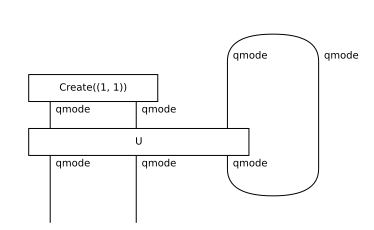

In [11]:
def random_unitary(size, seed=7):
    rng = np.random.default_rng(seed)
    matrix = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    unitary, upper = np.linalg.qr(matrix)
    return unitary * (np.diag(upper) / np.abs(np.diag(upper)))


U = photonic.Gate(random_unitary(3), 3, 3, "U")

def feedback_sampler(occupation):
    psi = photonic.Create(*occupation)
    return (psi @ qmode >> U).feedback(
        mem=qmode, initial_state=photonic.Create(0))

process = feedback_sampler((1, 1))
process.draw(figsize=(5, 3))

One step contains the two maps the paper uses. Tracing out the detected
modes updates the loop state,
$\rho \mapsto \mathrm{Tr}_{\mathrm{det}}[U(|\psi\rangle\langle\psi|
\otimes\rho)U^\dagger]$; tracing out the next memory instead gives the
visible output. `method="power"` iterates the first map through a finite
tensor-network unrolling and applies the readout once at the end;
`method="eigen"` builds the transfer operator of that map, solves for its
stationary eigenstate $\rho_\star$, and applies the same readout once.

Drawn as an equation, with one box standing for the computed stationary
memory:

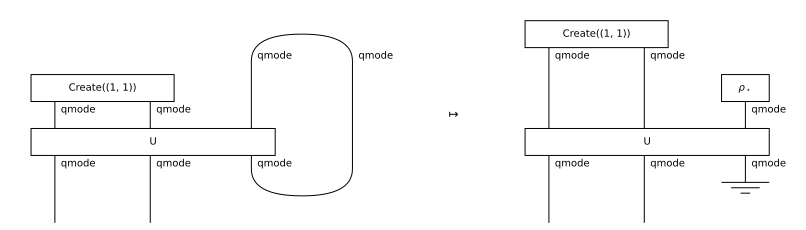

In [12]:
stationary = Channel(
    r"$\rho_\star$",
    diagram.Box(r"$\rho_\star$", diagram.Ty(), diagram.Mode(2)),
    cod=qmode, env=diagram.Mode(1))
readout = (photonic.Create(1, 1) @ stationary >> U
           >> Diagram.id(qmode ** 2) @ Discard(qmode))
Equation(process, readout, symbol=r"$\mapsto$").draw(figsize=(11, 3))

Both routes should agree wherever both are affordable. The power method
approaches the eigen result as the unrolling deepens.

In [13]:
def padded_distance(left, right):
    shape = tuple(max(a, b) for a, b in zip(left.shape, right.shape))
    def pad(array):
        out = np.zeros(shape, dtype=complex)
        out[tuple(slice(0, n) for n in array.shape)] = array
        return out
    return np.linalg.norm(pad(left) - pad(right))


depths = (2, 4, 6)
print("psi       " + "".join(f"{d:>12d} steps" for d in depths))
for occupation in ((1, 0), (0, 1), (1, 1)):
    sampler = feedback_sampler(occupation)
    reference = sampler.fix(method="eigen", cutoff=9).density_matrix
    row = [padded_distance(
        sampler.fix(n_steps=d, chi=16,
                    backend=DiscopyBackend()).density_matrix, reference)
        for d in depths]
    print(f"{str(occupation):10s}" + "".join(f"{v:18.2e}" for v in row))

psi                  2 steps           4 steps           6 steps


(1, 0)              7.52e-02          2.75e-04          1.35e-06


(0, 1)              8.79e-03          4.23e-05          2.08e-07


(1, 1)              3.37e-02          1.07e-04          5.26e-07


## Further reading

The transfer/readout construction follows Yu. A. Biriukov and I. V. Dyakonov,
[Simulation of boson sampling with optical
feedback](https://doi.org/10.48550/arXiv.2602.05566), arXiv:2602.05566
[quant-ph] (2026).

The loop of Part 1 is the unconditional counterpart of the heralded scheme in
Mendei, Homa, Ádám and Koniorczyk, [Photon number states via iterated photon
addition in a loop](https://doi.org/10.3390/photonics11111075), *Photonics*
**11**(11) 1075 (2024): the same hardware, but conditioning on detector clicks
builds Fock states, whereas discarding the output leaves the mixture computed
here. That the loop cannot converge to the injected Fock state is the
Fock-state exception to quantum homogenization, M. Ziman et al., [Phys. Rev. A
**66**, 062307](https://doi.org/10.1103/PhysRevA.66.062307) (2002).